In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

data = {
    "지점": [
        "강남", "강남", "강남", "홍대", "홍대",
        "홍대", "종로", "종로", "종로", "종로"
    ],
    "메뉴": [
        "아메리카노", "라떼", "케이크",
        "아메리카노", "라떼", "케이크",
        "아메리카노", "라떼", "케이크", "아메리카노"
    ],
    "가격": [
        4500, 5500, 7000,
        4500, 5500, 7000,
        4500, 5500, 7000, 4500
    ],
    "판매량": [
        120, 80, 30,
        150, 60, 45,
        90, 100, 25, 110
    ],
    "평점": [
        4.5, 4.2, 4.8,
        4.7, 3.9, 4.6,
        4.1, np.nan, 4.9, 4.3
    ]
}

df = pd.DataFrame(data)

In [11]:
# df의 행/열 개수, 컬럼 이름, 각 컬럼의 자료형을 확인하세요.
df.head()
df.dtypes

지점         str
메뉴         str
가격       int64
판매량      int64
평점     float64
dtype: object

In [15]:
# 처음 5개의 데이터만 출력하세요.
df[["지점", "메뉴", "판매량"]]

,지점,메뉴,판매량
0,강남,아메리카노,120
1,강남,라떼,80
2,강남,케이크,30
3,홍대,아메리카노,150
4,홍대,라떼,60
5,홍대,케이크,45
6,종로,아메리카노,90
7,종로,라떼,100
8,종로,케이크,25
9,종로,아메리카노,110


In [17]:
# 판매량이 100 이상인 데이터만 추출하세요.
df_mask = df["판매량"] >= 100
df[df_mask]

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
3,홍대,아메리카노,4500,150,4.7
7,종로,라떼,5500,100,NaN
9,종로,아메리카노,4500,110,4.3


In [22]:
# 판매량이 100 이상이면서 메뉴가 아메리카노인 데이터만 추출하세요.
df_mask  = (df["메뉴"] == "아메리카노") & (df["판매량"] >= 100)
df[df_mask]

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
3,홍대,아메리카노,4500,150,4.7
7,종로,아메리카노,5500,100,NaN
9,종로,아메리카노,4500,110,4.3


In [10]:
# "매출"이라는 새로운 컬럼을 만드세요.
df["매출"] = df["가격"] * df["판매량"]
df

,지점,메뉴,가격,판매량,평점,매출
0,강남,아메리카노,4500,120,4.5,540000
1,강남,라떼,5500,80,4.2,440000
2,강남,케이크,7000,30,4.8,210000
3,홍대,아메리카노,4500,150,4.7,675000
4,홍대,라떼,5500,60,3.9,330000
5,홍대,케이크,7000,45,4.6,315000
6,종로,아메리카노,4500,90,4.1,405000
7,종로,라떼,5500,100,NaN,550000
8,종로,케이크,7000,25,4.9,175000
9,종로,아메리카노,4500,110,4.3,495000


In [36]:
# 매출이 가장 높은 행을 찾아서 지점, 메뉴, 매출을 출력하세요. 지금 배운 max()나 argmax()/idxmax() 등을 생각해보세요.


In [15]:
# groupby()를 이용해서 지점별 총 매출을 구하세요.
df.groupby("지점").sum()["매출"]
df.groupby("지점")["매출"].sum()

지점
강남    1190000
종로    1625000
홍대    1320000
Name: 매출, dtype: int64

In [22]:
# roupby()를 이용해서 메뉴별 평균 판매량을 구하세요.
round(df.groupby("메뉴")["판매량"].mean(), 2)

메뉴
라떼        80.00
아메리카노    117.50
케이크       33.33
Name: 판매량, dtype: float64

In [50]:
# 지점별로 데이터가 몇 개씩 있는지 구하세요.
df.groupby("지점").size()

지점
강남    3
종로    4
홍대    3
dtype: int64

In [49]:
# "평점"에 결측값(NaN)이 몇 개 있는지 확인하세요.
df["평점"].isna().sum()

np.int64(1)

In [59]:
# apply()와 함수를 이용해서 "평가"라는 파생변수를 만드세요.
# 평점이 NaN → "평가 없음"
# 평점 >= 4.5 → "우수"
# 나머지 → "보통"

def df_score(score):
    if pd.isna(score):
        return "평가 없음"
    if score >= 4.5:
        return "우수"
    else:
        return "보통"

df["평가"] = df["평점"].apply(df_score)
df

,지점,메뉴,가격,판매량,평점,매출,평가
0,강남,아메리카노,4500,120,4.5,540000,우수
1,강남,라떼,5500,80,4.2,440000,보통
2,강남,케이크,7000,30,4.8,210000,우수
3,홍대,아메리카노,4500,150,4.7,675000,우수
4,홍대,라떼,5500,60,3.9,330000,보통
5,홍대,케이크,7000,45,4.6,315000,우수
6,종로,아메리카노,4500,90,4.1,405000,보통
7,종로,라떼,5500,100,NaN,550000,평가 없음
8,종로,케이크,7000,25,4.9,175000,우수
9,종로,아메리카노,4500,110,4.3,495000,보통


In [67]:
# 전체 판매량의 평균, 편차, 편차의 제곱, 분산, 표준편차를 직접 구해보세요. 처음부터 std()를 쓰지 말고 지금 배운 방식으로 계산합니다.
mean = df["판매량"].mean()
print(df["판매량"] - mean)
df["편차제곱"] = (df["판매량"] - mean) ** 2
df["편차제곱"].mean() ** 0.5

0    39.0
1    -1.0
2   -51.0
3    69.0
4   -21.0
5   -36.0
6     9.0
7    19.0
8   -56.0
9    29.0
Name: 판매량, dtype: float64


np.float64(38.781438859330635)

In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [14]:
base_path = r"E:\kdt_0900_sal\data_analysis\resource\dataset"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)

In [15]:
hr_df = pd.read_csv(file_path)
hr_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


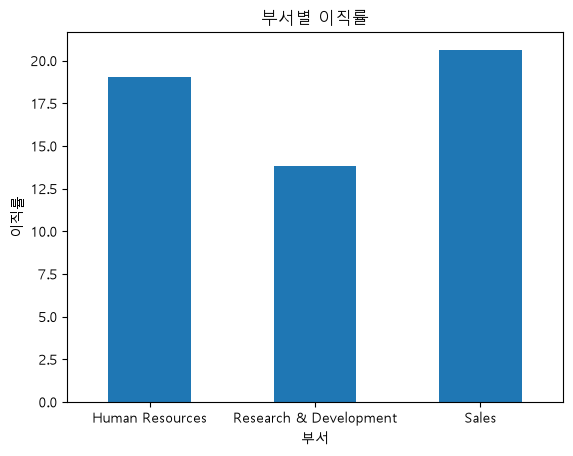

In [16]:
# ==============================================================================
# [실습 문제 1] 부서별(Department) 이직률 분석
# ==============================================================================
# 1. 부서별(Department) 이직 여부(Attrition)의 비율(%) 구하기
# 2. 부서별 이직률을 비교할 수 있는 막대 그래프(Bar plot) 시각화
# 3. 가장 이직률이 높은 부서 간단히 작성

department_attrition = hr_df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
department_attrition.plot(kind="bar")
plt.title("부서별 이직률")
plt.xlabel("부서")
plt.ylabel("이직률")
plt.xticks(rotation=0)
plt.show()

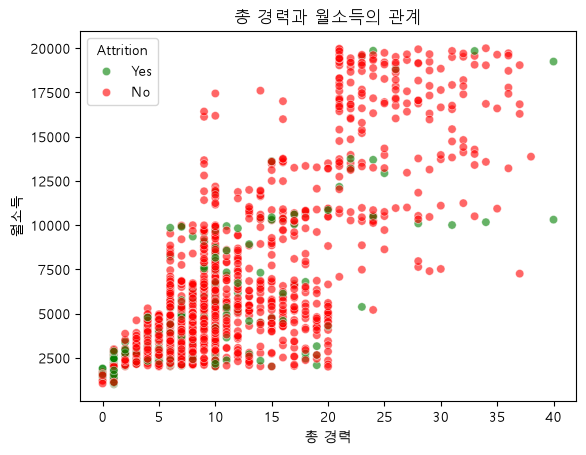

In [17]:
# ==============================================================================
# [실습 문제 2] 총 경력(TotalWorkingYears)과 월소득(MonthlyIncome)의 관계
# ==============================================================================
# 1. x축: TotalWorkingYears, y축: MonthlyIncome 산점도(Scatter plot) 그리기
# 2. 이직 여부(Attrition)에 따라 점 색상 다르게 표현 (hue='Attrition')
# 3. 경력과 월소득의 상관관계 및 이직자 분포 특징 서술
sns.scatterplot(data=hr_df, x="TotalWorkingYears", y="MonthlyIncome", hue="Attrition", alpha=0.6, palette=["green", "red"])
plt.title("총 경력과 월소득의 관계")
plt.xlabel("총 경력")
plt.ylabel("월소득")
plt.show()

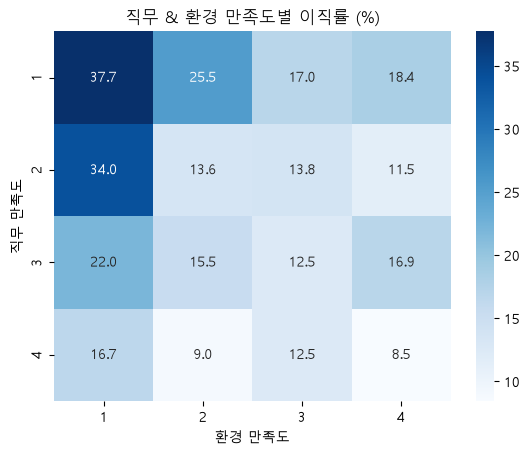

In [18]:
# ==============================================================================
# [실습 문제 3] 직무 만족도 & 환경 만족도 복합 분석
# ==============================================================================
# 1. JobSatisfaction과 EnvironmentSatisfaction 조합별 이직률 히트맵(Heatmap) 그리기
# 2. 어떤 만족도 조합에서 이직률이 가장 높은지 서술
pivot_df = hr_df.pivot_table(
    index="JobSatisfaction",
    columns="EnvironmentSatisfaction",
    values="Attrition",
    aggfunc=lambda x: (x == "Yes").mean() * 100,
)

sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="Blues")

plt.title("직무 & 환경 만족도별 이직률 (%)")
plt.xlabel("환경 만족도")
plt.ylabel("직무 만족도")
plt.show()

In [19]:
# ==============================================================================
# [실습 문제 4] 나이(Age) 구간별 이직 위험도 파악
# ==============================================================================
# 1. Age 컬럼으로 '20대 이하', '30대', '40대', '50대 이상' 파생변수 'AgeGroup' 생성
# 2. 연령대 그룹별 이직률(%) 계산 후 시각화 (Barplot 또는 Lineplot)
# 3. 이직 위험도가 가장 높은 연령대 서술
def age_group(age):
    if age < 30:
        return "20대 이하"
    elif age < 40:
        return "30대"
    elif age < 50:
        return "40대"
    else:
        return "50대 이상"

In [20]:
hr_df["AgeGroup"] = hr_df["Age"].apply(age_group)

In [21]:
age_attrition = hr_df.groupby("AgeGroup")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

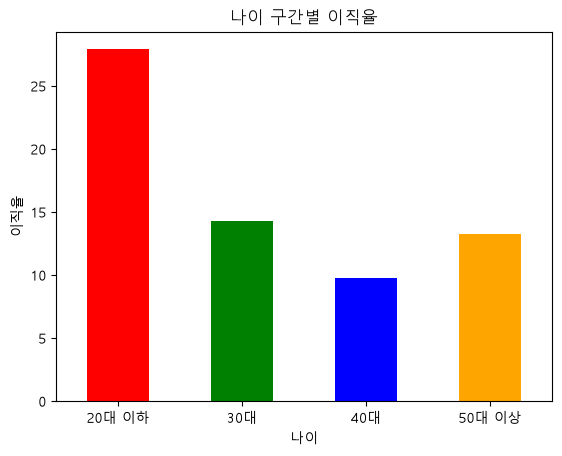

In [26]:
age_attrition.plot(kind="bar", color=["red", "green", "blue", "orange"])
plt.title("나이 구간별 이직율")
plt.xlabel("나이")
plt.ylabel("이직율")
plt.xticks(rotation=0)
plt.show()

In [5]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "name": ["A", "B", "C", "D", "E", "F", "F"],
    "age": [23, 31, np.nan, 27, 45, 150, 150],
    "salary": [3000, 4200, 3500, np.nan, 5100, 100000, 100000],
    "department": ["개발", "영업", "개발", "영업", np.nan, "개발", "개발"],
    "attrition": ["No", "Yes", "No", "Yes", "No", "Yes", "Yes"]
})

df

,name,age,salary,department,attrition
0,A,23.0,3000.0,개발,No
1,B,31.0,4200.0,영업,Yes
2,C,NaN,3500.0,개발,No
3,D,27.0,NaN,영업,Yes
4,E,45.0,5100.0,NaN,No
5,F,150.0,100000.0,개발,Yes
6,F,150.0,100000.0,개발,Yes


In [6]:
# 1번. 데이터 기본 정보 확인
# 1. 데이터의 상위 5개 행을 출력하시오.
# 2. 행과 열의 개수를 확인하시오.
# 3. 각 컬럼의 데이터 타입 및 결측치 여부를 확인하시오.
# 4. 숫자형 데이터의 기초 통계량을 확인하시오.

# 답안
df.head()
len(df.index)
len(df.columns)
df.shape  # 행열 갯수
df.isna().sum()
df.describe()   # 기초통계량


,age,salary
count,6.000000,6.000000
mean,71.000000,35966.666667
std,61.640896,49605.026627
min,23.000000,3000.000000
25%,28.000000,3675.000000
50%,38.000000,4650.000000
75%,123.750000,76275.000000
max,150.000000,100000.000000


In [7]:
# 2번. 결측치 및 중복 데이터 전처리
# 1. 각 컬럼의 결측치 개수를 확인하시오.
# 2. age의 결측치는 age의 중앙값으로 대체하시오.
# 3. salary의 결측치는 salary의 평균값으로 대체하시오.
# 4. department의 결측치는 최빈값으로 대체하시오.
# 5. 완전히 중복된 행은 제거하시오.
# 6. 중복 제거 후 인덱스를 다시 설정하시오.

# 답안
df.isna().sum()
df["age"] = df["age"].fillna(df["age"].median())
df["salary"] = df["salary"].fillna(df["salary"].mean())
df["department"] = df["department"].fillna(df["department"].mode()[0])
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df

,name,age,salary,department,attrition
0,A,23.0,3000.000000,개발,No
1,B,31.0,4200.000000,영업,Yes
2,C,38.0,3500.000000,개발,No
3,D,27.0,35966.666667,영업,Yes
4,E,45.0,5100.000000,개발,No
5,F,150.0,100000.000000,개발,Yes


In [8]:
# 3번. 이상치 처리
# salary 컬럼에 대해 IQR 방식으로 이상치를 판단하여 제거하시오.
# 1. Q1을 계산하시오.
# 2. Q3를 계산하시오.
# 3. IQR을 계산하시오.
# 4. 정상 데이터의 최소 기준값과 최대 기준값을 계산하시오.
# 5. 이상치를 제외한 데이터만 clean_df에 저장하시오.

# 답안
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
clean_df = df[
    (df["salary"] >= lower) &
    (df["salary"] <= upper)
]
clean_df

,name,age,salary,department,attrition
0,A,23.0,3000.000000,개발,No
1,B,31.0,4200.000000,영업,Yes
2,C,38.0,3500.000000,개발,No
3,D,27.0,35966.666667,영업,Yes
4,E,45.0,5100.000000,개발,No


In [15]:
# 4번. 조건에 맞는 데이터 조회
# clean_df를 사용하여 다음 조건을 만족하는 코드를 작성하시오.
# 1. 나이가 30세 이상인 데이터만 조회하시오.
# 2. 부서가 "개발"인 데이터만 조회하시오.
# 3. salary가 높은 순서대로 정렬하시오.
# 4. age, salary 컬럼만 출력하시오.

# 답안
clean_df[clean_df["age"] >= 30]
clean_df[clean_df["department"] == "개발"]
clean_df.sort_values(by="salary", ascending=False)[["age", "salary"]]

,age,salary
3,27.0,35966.666667
4,45.0,5100.000000
1,31.0,4200.000000
2,38.0,3500.000000
0,23.0,3000.000000


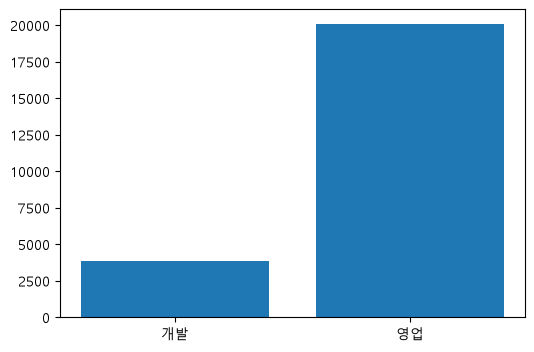

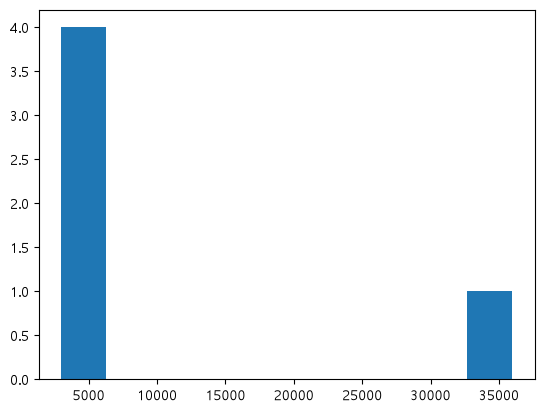

In [38]:
# 5번. 그룹별 데이터 분석 및 시각화
# clean_df를 이용하여 다음 결과를 구하시오.

# 1. department별 평균 salary를 구하시오.
# 2. department별 인원 수를 구하시오.
# 3. attrition별 평균 age를 구하시오.
# 4. department별 salary의 count, mean, min, max를 한 번에 조회하시오.
# 5. department별 평균 salary를 막대그래프로 시각화하시오.
# 6. salary의 분포를 히스토그램으로 시각화하시오.

# 답안
df_mean = clean_df.groupby("department")["salary"].mean()
clean_df.groupby("department").size()
clean_df.groupby("attrition")["age"].mean()
clean_df.groupby("department")["salary"].agg(["count", "mean", "min", "max"])

plt.figure(figsize=(6, 4))
plt.bar(df_mean.index, df_mean.values)
plt.show()
plt.hist(clean_df["salary"])
plt.show()

In [39]:
# 6번. 주가 데이터 EDA

close_df = pd.DataFrame({
    "NVDA": [100, 102, 101, 105, 110],
    "AAPL": [200, 198, 202, 205, 210],
    "JEPI": [55, 55.5, 55.2, 56, 56.5]
})

close_df

,NVDA,AAPL,JEPI
0,100,200,55.0
1,102,198,55.5
2,101,202,55.2
3,105,205,56.0
4,110,210,56.5


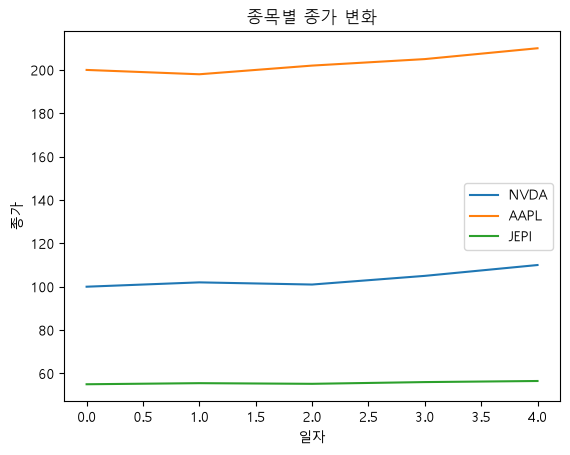

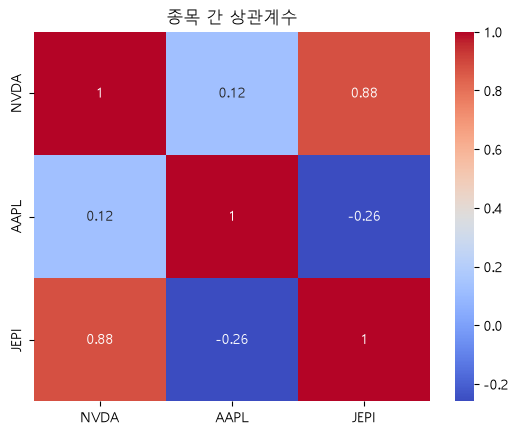

In [43]:
# 다음 요구사항을 만족하는 코드를 작성하시오.

# 1. 전일 대비 일별 수익률을 계산하여 returns_df에 저장하시오.
# 2. 수익률 계산으로 발생한 결측치를 제거하시오.
# 3. 각 종목의 누적 수익률을 계산하시오.
# 4. 각 종목별 평균 일별 수익률을 계산하시오.
# 5. 각 종목별 수익률의 표준편차를 계산하시오.
# 6. 종목 간 상관계수를 확인하시오.
# 7. 각 종목의 종가 변화를 선그래프로 시각화하시오.
# 8. 종목 간 상관계수를 히트맵으로 시각화하시오.

# 답안
# 1. 전일 대비 일별 수익률 계산
returns_df = close_df.pct_change()

# 2. 결측치 제거해서 returns_df에 저장 (★ 중요)
returns_df = returns_df.dropna()

# 3. 각 종목의 누적 수익률
cum_returns = returns_df.cumsum()

# 4. 각 종목별 평균 일별 수익률
mean_returns = returns_df.mean()

# 5. 각 종목별 수익률의 표준편차
std_returns = returns_df.std()

# 6. 종목 간 상관계수
corr_matrix = returns_df.corr()

# 7. 각 종목의 종가 변화 선그래프
close_df.plot(kind="line")
plt.title("종목별 종가 변화")
plt.xlabel("일자")
plt.ylabel("종가")
plt.show()

# 8. 종목 간 상관계수 히트맵
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("종목 간 상관계수")
plt.show()

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "product": ["A", "B", "C", "D", "E", "F", "F"],
    "price": [12000, 15000, np.nan, 18000, 20000, 999999, 999999],
    "stock": [10, 5, 8, np.nan, 20, 3, 3],
    "category": ["식품", "전자", "식품", "전자", np.nan, "식품", "식품"],
    "sold": [5, 2, 7, 1, 9, 3, 3]
})

df

,product,price,stock,category,sold
0,A,12000.0,10.0,식품,5
1,B,15000.0,5.0,전자,2
2,C,NaN,8.0,식품,7
3,D,18000.0,NaN,전자,1
4,E,20000.0,20.0,NaN,9
5,F,999999.0,3.0,식품,3
6,F,999999.0,3.0,식품,3


In [81]:
# 1번. 결측치와 중복 데이터 전처리

# 1. 각 컬럼별 결측치 개수를 확인하시오.
# 2. price의 결측치를 price의 중앙값으로 대체하시오.
# 3. stock의 결측치를 stock의 평균값으로 대체하시오.
# 4. category의 결측치를 category의 최빈값으로 대체하시오.
# 5. 중복된 행을 제거하시오.
# 6. 인덱스를 0부터 다시 설정하시오.

# 답안
df.isna().sum()
df["price"] = df["price"].fillna(df["price"].median())
df["stock"] = df["stock"].fillna(df["stock"].mean())
df["category"] = df["category"].fillna(df["category"].mode()[0])
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df

,product,price,stock,category,sold
0,A,12000.0,10.000000,식품,5
1,B,15000.0,5.000000,전자,2
2,C,19000.0,8.000000,식품,7
3,D,18000.0,8.166667,전자,1
4,E,20000.0,20.000000,식품,9
5,F,999999.0,3.000000,식품,3


In [82]:
# 2번. 새로운 컬럼 생성 및 조건 필터링

# 1. price * sold 값을 계산하여 revenue 컬럼을 생성하시오.
# 2. revenue가 100000 이상인 데이터만 high_revenue에 저장하시오.
# 3. high_revenue를 revenue가 높은 순서대로 정렬하시오.
# 4. product, category, revenue 컬럼만 출력하시오.

# 답안
df["revenue"] = df["price"] * df["sold"]
high_revenue = df[df["revenue"] >= 100000]
high_revenue = high_revenue.sort_values(by="revenue", ascending=False)
df[["product", "category", "revenue"]]

,product,category,revenue
0,A,식품,60000.0
1,B,전자,30000.0
2,C,식품,133000.0
3,D,전자,18000.0
4,E,식품,180000.0
5,F,식품,2999997.0


In [83]:
# 3번. 그룹별 데이터 분석

# 1. category별 평균 price를 구하시오.
# 2. category별 sold의 합계를 구하시오.
# 3. category별 상품 개수를 구하시오.
# 4. category별 price의 count, mean, min, max를 한 번에 출력하시오.

# 답안
df.groupby("category")["price"].mean()
df.groupby("category")["sold"].sum()
df.groupby("category").size()
df.groupby("category")["price"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
category,,,,
식품,4,262749.75,12000.0,999999.0
전자,2,16500.00,15000.0,18000.0


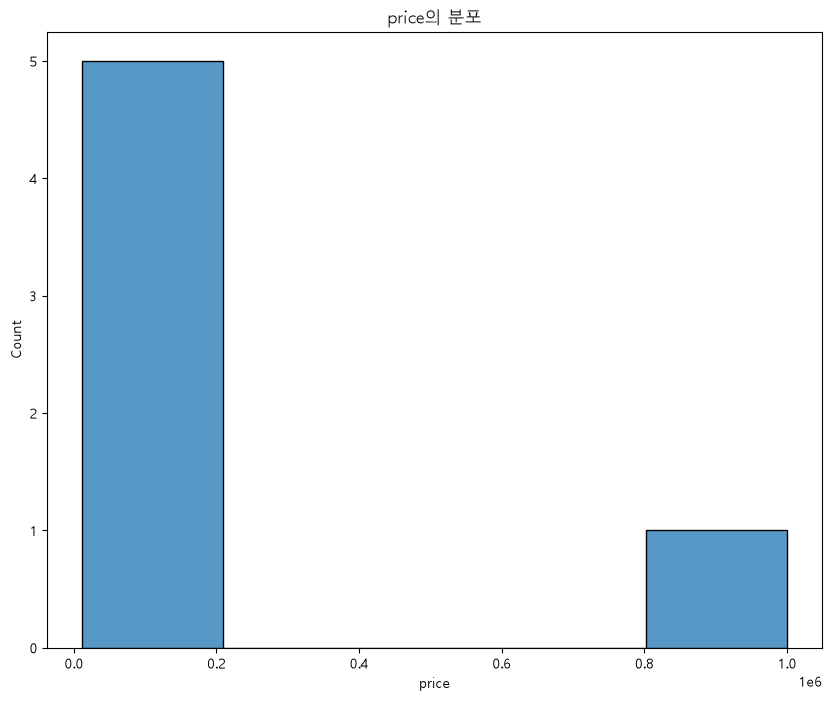

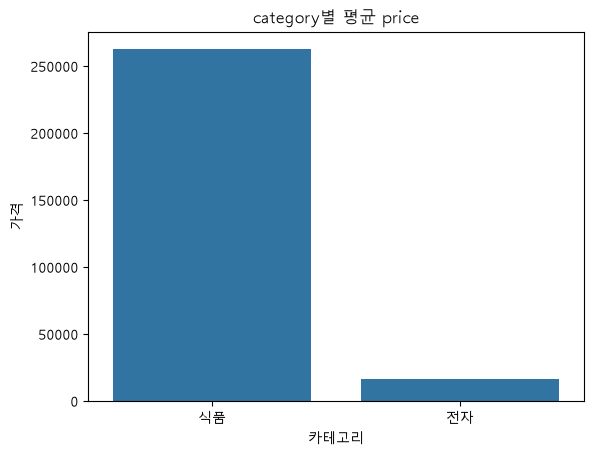

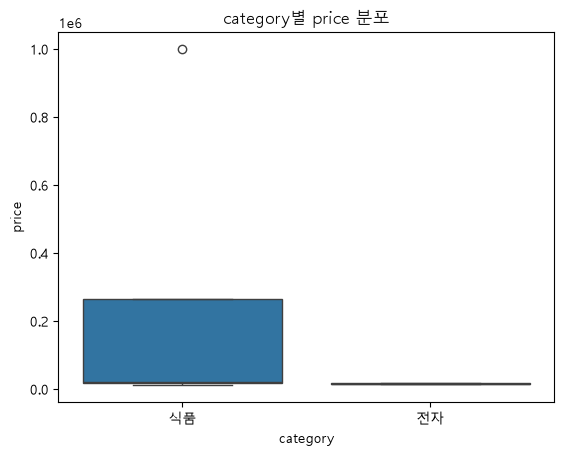

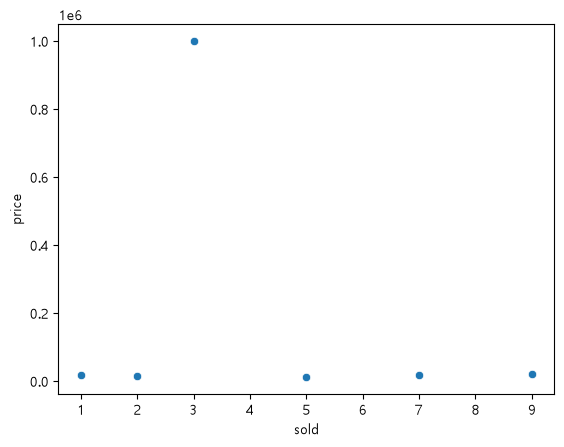

In [111]:
# 4번. Seaborn을 이용한 데이터 시각화

# df를 이용하여 다음 그래프를 작성하시오.

# 1. price의 분포를 histplot으로 시각화하시오.
# 2. category별 평균 price를 barplot으로 시각화하시오.
# 3. category별 price 분포를 boxplot으로 시각화하시오.
# 4. price와 sold의 관계를 scatterplot으로 시각화하시오.

# 각 그래프 출력 후 plt.show()를 사용하시오.

# 답안
plt.figure(figsize=(10, 8))
sns.histplot(df["price"])
plt.title("price의 분포")
plt.show()

c_p_mean = df.groupby("category")["price"].mean()
sns.barplot(data=df, x="category", y="price", errorbar=None)
plt.title("category별 평균 price")
plt.xlabel("카테고리")
plt.ylabel("가격")
plt.show()

sns.boxplot(data=df, x="category", y="price")
plt.title("category별 price 분포")
plt.show()

sns.scatterplot(data=df, x="sold", y="price")
plt.show()

In [ ]:
# 5번. IQR 이상치 처리 및 시각화

# price 컬럼을 기준으로 다음 작업을 수행하시오.

# 1. Q1을 구하시오.
# 2. Q3를 구하시오.
# 3. IQR을 구하시오.
# 4. lower, upper를 계산하시오.
# 5. 정상 범위의 데이터만 clean_df에 저장하시오.
# 6. 이상치 제거 후 clean_df의 price를 boxplot으로 시각화하시오.

# 답안

In [ ]:
# 6번. 주가 데이터 EDA 및 시각화

close_df = pd.DataFrame({
    "TSLA": [250, 255, 248, 260, 270],
    "MSFT": [400, 405, 410, 408, 415],
    "KO": [60, 60.5, 60.2, 61, 61.3]
})

# 다음 작업을 수행하시오.

# 1. 전일 대비 일별 수익률을 계산하여 returns_df에 저장하시오.
# 2. 수익률 계산으로 발생한 결측치를 제거하시오.
# 3. 각 종목의 평균 수익률을 구하시오.
# 4. 각 종목의 수익률 표준편차를 구하시오.
# 5. 종목 간 상관계수를 확인하시오.
# 6. close_df의 종가 변화를 선그래프로 시각화하시오.
# 7. returns_df의 상관계수를 seaborn heatmap으로 시각화하시오.
# 8. heatmap 안에 상관계수 값이 표시되도록 하시오.

# 답안